# Pandas puzzles

Inspired by [100 Numpy exerises](https://github.com/rougier/numpy-100), here are 100* short puzzles for testing your knowledge of [pandas'](http://pandas.pydata.org/) power.

Since pandas is a large library with many different specialist features and functions, these exercises focus mainly on the fundamentals of manipulating data (indexing, grouping, aggregating, cleaning), making use of the core DataFrame and Series objects. 

Many of the exercises here are stright-forward in that the solutions require no more than a few lines of code (in pandas or NumPy... don't go using pure Python or Cython!). Choosing the right methods and following best practices is the underlying goal.

The exercises are loosely divided in sections. Each section has a difficulty rating; these ratings are subjective, of course, but should be a seen as a rough guide as to how inventive the required solution is.

If you're just starting out with pandas and you are looking for some other resources, the official documentation  is very extensive. In particular, some good places get a broader overview of pandas are...

- [10 minutes to pandas](http://pandas.pydata.org/pandas-docs/stable/10min.html)
- [pandas basics](http://pandas.pydata.org/pandas-docs/stable/basics.html)
- [tutorials](http://pandas.pydata.org/pandas-docs/stable/tutorials.html)
- [cookbook and idioms](http://pandas.pydata.org/pandas-docs/stable/cookbook.html#cookbook)

Enjoy the puzzles!

## Importing pandas

### Getting started and checking your pandas setup

Difficulty: *easy* 

**1.** Import pandas under the name `pd`.

In [1]:
import pandas as pd
import numpy as np


**2.** Print the version of pandas that has been imported.

In [5]:
pd.__version__

'2.2.3'

**3.** Print out all the version information of the libraries that are required by the pandas library.

In [6]:
pd.show_versions()


INSTALLED VERSIONS
------------------
commit                : 0691c5cf90477d3503834d983f69350f250a6ff7
python                : 3.11.9
python-bits           : 64
OS                    : Windows
OS-release            : 10
Version               : 10.0.22631
machine               : AMD64
processor             : Intel64 Family 6 Model 154 Stepping 4, GenuineIntel
byteorder             : little
LC_ALL                : None
LANG                  : None
LOCALE                : Hebrew_Israel.1255

pandas                : 2.2.3
numpy                 : 2.1.2
pytz                  : 2024.2
dateutil              : 2.9.0.post0
pip                   : 24.0
Cython                : None
sphinx                : None
IPython               : 8.27.0
adbc-driver-postgresql: None
adbc-driver-sqlite    : None
bs4                   : 4.12.3
blosc                 : None
bottleneck            : None
dataframe-api-compat  : None
fastparquet           : None
fsspec                : None
html5lib              : No

## DataFrame basics

### A few of the fundamental routines for selecting, sorting, adding and aggregating data in DataFrames

Difficulty: *easy*

Note: remember to import numpy using:
```python
import numpy as np
```

Consider the following Python dictionary `data` and Python list `labels`:

``` python
data = {'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
        'age': [2.5, 3, 0.5, np.nan, 5, 2, 4.5, np.nan, 7, 3],
        'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
        'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']}

labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
```
(This is just some meaningless data I made up with the theme of animals and trips to a vet.)

**4.** Create a DataFrame `df` from this dictionary `data` which has the index `labels`.

In [2]:
import numpy as np
data = {'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
        'age': [2.5, 3, 0.5, np.nan, 5, 2, 4.5, np.nan, 7, 3],
        'visits': [1, 3, 2, 3, 2, 3, 1, 1, 2, 1],
        'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']}

labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']
df = pd.DataFrame(data, index=labels)

**5.** Display a summary of the basic information about this DataFrame and its data.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, a to j
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   animal    10 non-null     object 
 1   age       8 non-null      float64
 2   visits    10 non-null     int64  
 3   priority  10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 400.0+ bytes


**6.** Return the first 3 rows of the DataFrame `df`.

In [4]:
df.head(3)

,animal,age,visits,priority
a,cat,2.5,1,yes
b,cat,3.0,3,yes
c,snake,0.5,2,no


**7.** Select just the 'animal' and 'age' columns from the DataFrame `df`.

In [30]:
df.iloc[:,0:2]

,animal,age
a,cat,2.5
b,cat,3.0
c,snake,0.5
d,dog,NaN
e,dog,5.0
f,cat,2.0
g,snake,4.5
h,cat,NaN
i,dog,7.0
j,dog,3.0


**8.** Select the data in rows `[3, 4, 8]` *and* in columns `['animal', 'age']`.

In [33]:
df.iloc[[3,4,8],0:2]

,animal,age
d,dog,NaN
e,dog,5.0
i,dog,7.0


**9.** Select only the rows where the number of visits is greater than 3.

In [9]:

df[df['visits'] > 3]

,animal,age,visits,priority


**10.** Select the rows where the age is missing, i.e. is `NaN`.

In [10]:
df[df['age'].isnull()]

,animal,age,visits,priority
d,dog,NaN,3,yes
h,cat,NaN,1,yes


**11.** Select the rows where the animal is a cat *and* the age is less than 3.

In [12]:
filt=(df['animal']=='cat') & (df['age']<3)
df[filt]

,animal,age,visits,priority
a,cat,2.5,1,yes
f,cat,2.0,3,no


**12.** Select the rows the age is between 2 and 4 (inclusive)

In [52]:
df[df['age'].between(2, 4)]

,animal,age,visits,priority
a,cat,2.5,1,yes
b,cat,3.0,3,yes
f,cat,2.0,3,no
j,dog,3.0,1,no


**13.** Change the age in row 'f' to 1.5.

In [ ]:
df.loc['f', 'age'] = 1.5

**14.** Calculate the sum of all visits (the total number of visits).

In [54]:
df['visits'].sum()

np.int64(19)

**15.** Calculate the mean age for each different animal in `df`.

In [55]:
df.groupby('animal')['age'].mean()

animal
cat      2.5
dog      5.0
snake    2.5
Name: age, dtype: float64

**16.** Append a new row 'k' to `df` with your choice of values for each column. Then delete that row to return the original DataFrame.

In [59]:
df.loc['k'] = ['dog',5,  4,'yes']

print(df.loc['k'])
df = df.drop('k')

animal      dog
age           5
visits        4
priority    yes
Name: k, dtype: object


**17.** Count the number of each type of animal in `df`.

In [63]:
df.groupby('animal')['animal'].count()
#df['animal'].value_counts()

animal
cat      4
dog      4
snake    2
Name: animal, dtype: int64

**18.** Sort `df` first by the values in the 'age' in *decending* order, then by the value in the 'visit' column in *ascending* order.

In [14]:
df.sort_values(by=['age', 'visits'], ascending=[False, True], inplace=True)
df

,animal,age,visits,priority
i,dog,7.0,2,no
e,dog,5.0,2,no
g,snake,4.5,1,no
j,dog,3.0,1,no
b,cat,3.0,3,yes
a,cat,2.5,1,yes
f,cat,2.0,3,no
c,snake,0.5,2,no
h,cat,NaN,1,yes
d,dog,NaN,3,yes


**19.** The 'priority' column contains the values 'yes' and 'no'. Replace this column with a column of boolean values: 'yes' should be `True` and 'no' should be `False`.

In [66]:
df['priority'] = df['priority'].replace({'yes': True, 'no': False})
df.head()

,animal,age,visits,priority
a,cat,2.5,1,True
b,cat,3.0,3,True
c,snake,0.5,2,False
d,dog,NaN,3,True
e,dog,5.0,2,False


**20.** In the 'animal' column, change the 'snake' entries to 'python'.

In [70]:
df['animal']=df['animal'].replace('snake','python')
df.head()


,animal,age,visits,priority
a,cat,2.5,1,True
b,cat,3.0,3,True
c,python,0.5,2,False
d,dog,NaN,3,True
e,dog,5.0,2,False


**21.** For each animal type and each number of visits, find the mean age. In other words, each row is an animal, each column is a number of visits and the values are the mean ages (hint: use a pivot table).

In [73]:
df.pivot_table(index='animal', columns='visits', values='age')

visits,1,2,3
animal,,,
cat,2.5,NaN,2.5
dog,3.0,6.0,NaN
python,4.5,0.5,NaN


### query()

Now do 11 again, this time using the DataFrame.query() method.

In [16]:
df.query("animal == 'cat' & age < 3")

,animal,age,visits,priority
a,cat,2.5,1,yes
f,cat,2.0,3,no


Try doing question 12 using the DataFrame.query() method.

In [75]:
df.query('2 <= age <= 4')

,animal,age,visits,priority
a,cat,2.5,1,True
b,cat,3.0,3,True
f,cat,2.0,3,False
j,dog,3.0,1,False


Now, try creating a function get_range() that gets in input a dataframe and two values and gives back every animal whose age is between these two values. Check it with the values of question 12.

In [76]:
def get_range(df, val1, val2):
    return df.query('@val1 < age < @val2')
get_range(df, 2, 4)

,animal,age,visits,priority
a,cat,2.5,1,True
b,cat,3.0,3,True
j,dog,3.0,1,False


Now, create a function get_animals() that receives a dataframe and two animal names and return all the animals of the two given types in the dataframe, using query(). Check it with cat and snake.

In [77]:
def get_animals(df, anim1, anim2):
    return df.query('animal in (@anim1,@anim2)')
get_animals(df, 'cat','snake')

,animal,age,visits,priority
a,cat,2.5,1,True
b,cat,3.0,3,True
f,cat,2.0,3,False
h,cat,NaN,1,True


Try doing the get_range question, this time using the python format() method for strings.

In [78]:
def get_range(df, val1, val2):
    return df.query('{val_1} < age < {val_2}'.format(val_1 = val1, val_2 = val2))
get_range(df, 2, 4)

,animal,age,visits,priority
a,cat,2.5,1,True
b,cat,3.0,3,True
j,dog,3.0,1,False


## DataFrames: using complicated functions

Difficulty: *medium*

here you will be asked to generate your own test data and manipulate it using functions you will have to create.

**22.** Create a dataframe with 1000 rows and 3 columns. The columns are to be the following:
        - age: an integer, uniformly distributed between 20 to 65
        - skill: a float, normally distributed between 0 and 1, with expected value = 0.5 and standard deviation = 0.3
        - height: a float with 2 digits after the decimal point, between 1.5 to 2.0
you might want to use numpy.random

In [114]:

age = np.random.randint(20, 66, size=1000)

skill = np.clip(np.random.normal(0.5, 0.3, size=1000), 0, 1)

height = np.round(np.random.uniform(1.5, 2.0, size=1000), 2)

df = pd.DataFrame({
    'age': age,
    'skill': skill,
    'height': height
})

df.head()


,age,skill,height
0,36,0.352359,1.76
1,55,0.991568,1.61
2,40,0.000000,1.52
3,36,0.697870,1.85
4,45,1.000000,1.86


**23.** Add the dataframe a new columns, called salary, when:
        salary = 1000*((age^2)/1000 + 1.7*skill + 0.4*exp(-(height-1.7)**2)

In [115]:
df['salary'] = 1000 * ((df['age'] ** 2) / 1000 + 1.7 * df['skill'] + 
                       0.4 * np.exp(-(df['height'] - 1.7) ** 2))
df.head()


,age,skill,height,salary
0,36,0.352359,1.76,2293.573538
1,55,0.991568,1.61,5107.438986
2,40,0.000000,1.52,1987.247703
3,36,0.697870,1.85,2873.479174
4,45,1.000000,1.86,4114.889961


**24.** Split the dataframe to groups by the age left digit and by the age. for each group compute:
        - the number of rows
        - the mean salary
        - the maximum height

In [121]:
data = df.groupby([df['age'] // 10, 'age']).agg({
    'age': 'size',
    'salary': 'mean',
    'height': 'max'
})

print(data)

         age       salary  height
age age                          
2   20    20  1473.550940    1.99
    21    20  1649.773577    1.97
    22    18  1754.752575    1.99
    23    21  1858.642732    1.98
    24    22  1908.832947    1.99
    25    19  1849.447103    1.95
    26    21  1987.014846    2.00
    27    20  2075.300744    1.99
    28    19  1807.867110    2.00
    29    21  2039.556034    1.97
3   30    23  1999.127217    1.99
    31    31  2254.568463    1.98
    32    18  2194.295034    1.95
    33    29  2188.562245    1.99
    34    25  2484.647585    1.99
    35    18  2396.649531    1.99
    36    19  2607.692787    1.98
    37    22  2697.127799    1.95
    38    26  2780.126508    1.99
    39    28  2782.544419    1.98
4   40    18  2894.267342    1.96
    41    24  2851.464158    2.00
    42    17  2990.759703    1.90
    43    23  3127.723778    1.96
    44    28  3235.379674    1.97
    45    18  3377.191606    2.00
    46    14  3252.513580    2.00
    47    24  

**25.** Now split the dataframe to groups by age. for each group compute the mean salary, split by the sum of heights.

In [132]:
df2=df.groupby('age').agg(
    {'salary': 'mean',
    'height': 'sum'}
)

df2['res']=df2['salary']/df2['height']
df2.head()

,salary,height,res
age,,,
20,1473.550940,34.85,42.282667
21,1649.773577,34.57,47.722695
22,1754.752575,31.20,56.242070
23,1858.642732,36.81,50.492875
24,1908.832947,39.65,48.142067


**26.** Add these lines to your code:

        import matplotlib.pyplot as plt
        %matplotlib inline
        
Now try using the pd.DataFrame.plot function to show your data. Try also using pd.DataFrame.boxplot.

In [133]:
import matplotlib.pyplot as plt
%matplotlib inline

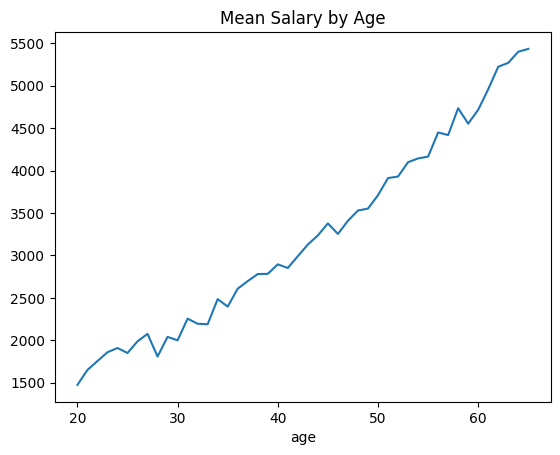

<Axes: >

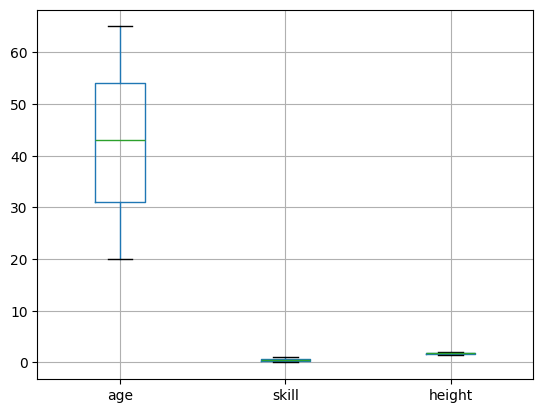

In [145]:
df2['salary'].plot(title="Mean Salary by Age")
plt.show()
df[['age', 'skill', 'height']].boxplot()


**27.** Save the result as a csv, then read the csv to the variable "data" using pandas

In [150]:
df2.to_csv("data1.csv")
df3 = pd.read_csv('data1.csv')
df3.head()

,age,salary,height,res
0,20,1473.550940,34.85,42.282667
1,21,1649.773577,34.57,47.722695
2,22,1754.752575,31.20,56.242070
3,23,1858.642732,36.81,50.492875
4,24,1908.832947,39.65,48.142067


## DataFrames: beyond the basics

### Slightly trickier: you may need to combine two or more methods to get the right answer

Difficulty: *medium*

The previous section was tour through some basic but essential DataFrame operations. Below are some ways that you might need to cut your data, but for which there is no single "out of the box" method.

**28.** You have a DataFrame `df` with a column 'A' of integers. For example:
```python
df = pd.DataFrame({'A': [1, 2, 2, 3, 4, 5, 5, 5, 6, 7, 7]})
```

How do you filter out rows which contain the same integer as the row immediately above?

In [ ]:
df = pd.DataFrame({'A': [1, 2, 2, 3, 4, 5, 5, 5, 6, 7, 7]})
df.loc[df['A'].shift() != df['A']]

,A
0,1
1,2
3,3
4,4
5,5
8,6
9,7


**29.** Given a DataFrame of numeric values, say
```python
df = pd.DataFrame(np.random.random(size=(5, 3))) # a 5x3 frame of float values
```

how do you subtract the row mean from each element in the row?

In [171]:
df = pd.DataFrame(np.random.random(size=(5, 3))) 
#df=df-df.mean(axis=1)
df = df.sub(df.mean(axis=1), axis=0)
df

,0,1,2
0,-0.237064,-0.220316,0.457381
1,0.539595,-0.284288,-0.255307
2,0.367900,-0.256370,-0.111529
3,0.264236,-0.114885,-0.149351
4,0.112424,-0.028039,-0.084385


**30.** Suppose you have DataFrame with 10 columns of real numbers, for example:

```python
df = pd.DataFrame(np.random.random(size=(5, 10)), columns=list('abcdefghij'))
```
Which column of numbers has the smallest sum? (Find that column's label.)

In [27]:
df = pd.DataFrame(np.random.random(size=(5, 10)), columns=list('abcdefghij'))
df.sum(axis=0).idxmin()

'f'

**31.** How do you count how many unique rows a DataFrame has (i.e. ignore all rows that are duplicates)?

In [178]:
len(df.drop_duplicates())


5

The next three puzzles are slightly harder...

**32.** You have a DataFrame that consists of 10 columns of floating--point numbers. Suppose that exactly 5 entries in each row are NaN values. For each row of the DataFrame, find the *column* which contains the *third* NaN value.

(You should return a Series of column labels.)

In [30]:

data = pd.DataFrame(np.random.random(size=(5, 10)), columns=list('abcdefghij'))
data[np.random.choice([True, False], size=data.shape)] = np.nan 
df = pd.DataFrame(data)

result = (df.isnull().cumsum(axis=1) == 3).idxmax(axis=1)
print(result)


0    h
1    a
2    h
3    d
4    g
dtype: object


**33.** A DataFrame has a column of groups 'grps' and and column of numbers 'vals'. For example: 

```python
df = pd.DataFrame({'grps': list('aaabbcaabcccbbc'), 
                   'vals': [12,345,3,1,45,14,4,52,54,23,235,21,57,3,87]})
```
For each *group*, find the sum of the three greatest values.

In [230]:
df = pd.DataFrame({'grps': list('aaabbcaabcccbbc'), 
                   'vals': [12, 345, 3, 1, 45, 14, 4, 52, 54, 23, 235, 21, 57, 3, 87]})

result = df.groupby('grps')['vals'].apply(lambda x: x.nlargest(3).sum())
print(result)

grps
a    409
b    156
c    345
Name: vals, dtype: int64


**34.** A DataFrame has two integer columns 'A' and 'B'. The values in 'A' are between 1 and 100 (inclusive). For each group of 10 consecutive integers in 'A' (i.e. `(0, 10]`, `(10, 20]`, ...), calculate the sum of the corresponding values in column 'B'.

In [31]:
df = pd.DataFrame({
    'A': np.arange(1, 101),
    'B': np.random.randint(1, 100, size=100)
})
df.groupby(pd.cut(df['A'], np.arange(0, 101, 10)))['B'].sum()

C:\Users\user\AppData\Local\Temp\ipykernel_10280\2823686176.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['A'], np.arange(0, 101, 10)))['B'].sum()


A
(0, 10]      520
(10, 20]     629
(20, 30]     451
(30, 40]     452
(40, 50]     567
(50, 60]     427
(60, 70]     389
(70, 80]     492
(80, 90]     551
(90, 100]    351
Name: B, dtype: int32

## DataFrames: harder problems 

### These might require a bit of thinking outside the box...

...but all are solvable using just the usual pandas/NumPy methods (and so avoid using explicit `for` loops).

Difficulty: *hard*

**35.** Consider a DataFrame `df` where there is an integer column 'X':
```python
df = pd.DataFrame({'X': [7, 2, 0, 3, 4, 2, 5, 0, 3, 4]})
```
For each value, count the difference back to the previous zero (or the start of the Series, whichever is closer). These values should therefore be `[1, 2, 0, 1, 2, 3, 4, 0, 1, 2]`. Make this a new column 'Y'.

In [283]:

df = pd.DataFrame({'X': [7, 2, 0, 3, 4, 2, 5, 0, 3, 4]})
df.groupby((df['X'] == 0).cumsum()).cumcount()


0    0
1    1
2    0
3    1
4    2
5    3
6    4
7    0
8    1
9    2
dtype: int64

**36.** Consider a DataFrame containing rows and columns of purely numerical data. Create a list of the row-column index locations of the 3 largest values.

In [298]:
df = pd.DataFrame({'X': [7, 2, 0, 13, 4, 2, 5, 0, 3, 4],
                   'Y': [4, 12, 11, 3, 4, 2, 5, 9, 3, 7]})

largest_values = df.stack().nlargest(3)

print(largest_values.index.tolist())


[(3, 'X'), (1, 'Y'), (2, 'Y')]


**37.** Given a DataFrame with a column of group IDs, 'grps', and a column of corresponding integer values, 'vals', replace any negative values in 'vals' with the group mean.

In [325]:

df = pd.DataFrame({
    'grps': ['A', 'A', 'A', 'B', 'B', 'B'],
    'vals': [1, -2, 3, -4, 5, 6]
})
group_means = df.groupby('grps')['vals'].transform('mean')
 
df['vals'] = df['vals'].where(df['vals'] >= 0, group_means)

df

,grps,vals
0,A,1.000000
1,A,0.666667
2,A,3.000000
3,B,2.333333
4,B,5.000000
5,B,6.000000


**38.** Implement a rolling mean over groups with window size 3, which ignores NaN value. For example consider the following DataFrame:

```python
>>> df = pd.DataFrame({'group': list('aabbabbbabab'),
                       'value': [1, 2, 3, np.nan, 2, 3, 
                                 np.nan, 1, 7, 3, np.nan, 8]})
>>> df
   group  value
0      a    1.0
1      a    2.0
2      b    3.0
3      b    NaN
4      a    2.0
5      b    3.0
6      b    NaN
7      b    1.0
8      a    7.0
9      b    3.0
10     a    NaN
11     b    8.0
```
The goal is to compute the Series:

```
0     1.000000
1     1.500000
2     3.000000
3     3.000000
4     1.666667
5     3.000000
6     3.000000
7     2.000000
8     3.666667
9     2.000000
10    4.500000
11    4.000000
```
E.g. the first window of size three for group 'b' has values 3.0, NaN and 3.0 and occurs at row index 5. Instead of being NaN the value in the new column at this row index should be 3.0 (just the two non-NaN values are used to compute the mean (3+3)/2)

In [358]:
df = pd.DataFrame({'group': list('aabbabbbabab'),
                   'value': [1, 2, 3, np.nan, 2, 3,np.nan, 1, 7, 3, np.nan, 8]})

df['avg_3'] = df.groupby('group')['value'].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
print(df)


   group  value     avg_3
0      a    1.0  1.000000
1      a    2.0  1.500000
2      b    3.0  3.000000
3      b    NaN  3.000000
4      a    2.0  1.666667
5      b    3.0  3.000000
6      b    NaN  3.000000
7      b    1.0  2.000000
8      a    7.0  3.666667
9      b    3.0  2.000000
10     a    NaN  4.500000
11     b    8.0  4.000000


## Series and DatetimeIndex

### Exercises for creating and manipulating Series with datetime data

Difficulty: *easy/medium*

pandas is fantastic for working with dates and times. These puzzles explore some of this functionality.


**39.** Create a DatetimeIndex that contains each business day of 2015 and use it to index a Series of random numbers. Let's call this Series `s`.

In [360]:
date1 = pd.date_range(start='2015-01-01', end='2015-12-31', freq='B') 
s = pd.Series(np.random.rand(len(date1)), index=date1)
s

2015-01-01    0.105605
2015-01-02    0.144497
2015-01-05    0.487706
2015-01-06    0.896332
2015-01-07    0.600755
                ...   
2015-12-25    0.357389
2015-12-28    0.200186
2015-12-29    0.397828
2015-12-30    0.464107
2015-12-31    0.043756
Freq: B, Length: 261, dtype: float64

**40.** Find the sum of the values in `s` for every Wednesday.

In [361]:
s[s.index.weekday == 2].sum() 

np.float64(27.53244272652715)

**41.** For each calendar month in `s`, find the mean of values.

In [362]:
s.groupby(s.index.month).mean()


1     0.506269
2     0.567822
3     0.591459
4     0.530483
5     0.518800
6     0.489611
7     0.416453
8     0.533296
9     0.472060
10    0.535373
11    0.368694
12    0.445279
dtype: float64

**42.** For each group of four consecutive calendar months in `s`, find the date on which the highest value occurred.

In [376]:
max_dates = s.groupby(pd.Grouper(freq='4M')).max()
print(max_dates)


2015-01-31    0.951854
2015-05-31    0.988385
2015-09-30    0.999689
2016-01-31    0.993492
Freq: 4ME, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_13400\2914890197.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  max_dates = s.groupby(pd.Grouper(freq='4M')).max()


**43.** Create a DateTimeIndex consisting of the third Thursday in each month for the years 2015 and 2016.

In [380]:
date1 = pd.date_range(start='2015-01-01', end='2016-12-31',freq='WOM-3THU') 
date1

DatetimeIndex(['2015-01-15', '2015-02-19', '2015-03-19', '2015-04-16',
               '2015-05-21', '2015-06-18', '2015-07-16', '2015-08-20',
               '2015-09-17', '2015-10-15', '2015-11-19', '2015-12-17',
               '2016-01-21', '2016-02-18', '2016-03-17', '2016-04-21',
               '2016-05-19', '2016-06-16', '2016-07-21', '2016-08-18',
               '2016-09-15', '2016-10-20', '2016-11-17', '2016-12-15'],
              dtype='datetime64[ns]', freq='WOM-3THU')

## Cleaning Data

### Making a DataFrame easier to work with

Difficulty: *easy/medium*

It happens all the time: someone gives you data containing malformed strings, Python, lists and missing data. How do you tidy it up so you can get on with the analysis?

Take this monstrosity as the DataFrame to use in the following puzzles:

```python
df = pd.DataFrame({'From_To': ['LoNDon_paris', 'MAdrid_miLAN', 'londON_StockhOlm', 
                               'Budapest_PaRis', 'Brussels_londOn'],
              'FlightNumber': [10045, np.nan, 10065, np.nan, 10085],
              'RecentDelays': [[23, 47], [], [24, 43, 87], [13], [67, 32]],
                   'Airline': ['KLM(!)', '<Air France> (12)', '(British Airways. )', 
                               '12. Air France', '"Swiss Air"']})
```
(It's some flight data I made up; it's not meant to be accurate in any way.)


In [434]:
df = pd.DataFrame({'From_To': ['LoNDon_paris', 'MAdrid_miLAN', 'londON_StockhOlm', 
                               'Budapest_PaRis', 'Brussels_londOn'],
              'FlightNumber': [10045, np.nan, 10065, np.nan, 10085],
              'RecentDelays': [[23, 47], [], [24, 43, 87], [13], [67, 32]],
                   'Airline': ['KLM(!)', '<Air France> (12)', '(British Airways. )', 
                               '12. Air France', '"Swiss Air"']})
df

,From_To,FlightNumber,RecentDelays,Airline
0,LoNDon_paris,10045.0,"[23, 47]",KLM(!)
1,MAdrid_miLAN,NaN,[],<Air France> (12)
2,londON_StockhOlm,10065.0,"[24, 43, 87]",(British Airways. )
3,Budapest_PaRis,NaN,[13],12. Air France
4,Brussels_londOn,10085.0,"[67, 32]","""Swiss Air"""


**44.** Some values in the the FlightNumber column are missing. These numbers are meant to increase by 10 with each row so 10055 and 10075 need to be put in place. Fill in these missing numbers and make the column an integer column (instead of a float column).

In [436]:
df['FlightNumber'] = df['FlightNumber'].interpolate().astype(int)
df

,From_To,FlightNumber,RecentDelays,Airline
0,LoNDon_paris,10045,"[23, 47]",KLM
1,MAdrid_miLAN,10055,[],Air France
2,londON_StockhOlm,10065,"[24, 43, 87]",British Airways
3,Budapest_PaRis,10075,[13],Air France
4,Brussels_londOn,10085,"[67, 32]",Swiss Air


**45.** The From\_To column would be better as two separate columns! Split each string on the underscore delimiter `_` to give a new temporary DataFrame with the correct values. Assign the correct column names to this temporary DataFrame. 

In [437]:
df2 = df['From_To'].str.split('_', expand=True)
df2

,0,1
0,LoNDon,paris
1,MAdrid,miLAN
2,londON,StockhOlm
3,Budapest,PaRis
4,Brussels,londOn


**46.** Notice how the capitalisation of the city names is all mixed up in this temporary DataFrame. Standardise the strings so that only the first letter is uppercase (e.g. "londON" should become "London".)

In [438]:
df2[0] = df2[0].str.capitalize()
df2[1] = df2[1].str.capitalize()
df2



,0,1
0,London,Paris
1,Madrid,Milan
2,London,Stockholm
3,Budapest,Paris
4,Brussels,London


**47.** Delete the From_To column from `df` and attach the temporary DataFrame from the previous questions.

In [439]:
df = df.drop('From_To', axis=1)
df = df.join(df2)
df = df.rename(columns={0: 'From', 1: 'To'})

df

,FlightNumber,RecentDelays,Airline,From,To
0,10045,"[23, 47]",KLM,London,Paris
1,10055,[],Air France,Madrid,Milan
2,10065,"[24, 43, 87]",British Airways,London,Stockholm
3,10075,[13],Air France,Budapest,Paris
4,10085,"[67, 32]",Swiss Air,Brussels,London


**48**. In the Airline column, you can see some extra puctuation and symbols have appeared around the airline names. Pull out just the airline name. E.g. `'(British Airways. )'` should become `'British Airways'`.

In [440]:
df['Airline'] = df['Airline'].str.extract('([a-zA-Z\s]+)')
df

,FlightNumber,RecentDelays,Airline,From,To
0,10045,"[23, 47]",KLM,London,Paris
1,10055,[],Air France,Madrid,Milan
2,10065,"[24, 43, 87]",British Airways,London,Stockholm
3,10075,[13],Air France,Budapest,Paris
4,10085,"[67, 32]",Swiss Air,Brussels,London


**49**. In the RecentDelays column, the values have been entered into the DataFrame as a list. We would like each first value in its own column, each second value in its own column, and so on. If there isn't an Nth value, the value should be NaN.

Expand the Series of lists into a DataFrame named `delays`, rename the columns `delay_1`, `delay_2`, etc. and replace the unwanted RecentDelays column in `df` with `delays`.

In [442]:
delays = df['RecentDelays'].apply(pd.Series)
delays.columns = ['delay_{}'.format(n) for n in range(1, len(delays.columns)+1)]

df = df.drop('RecentDelays', axis=1).join(delays)
df

,FlightNumber,Airline,From,To,delay_1,delay_2,delay_3
0,10045,KLM,London,Paris,23.0,47.0,NaN
1,10055,Air France,Madrid,Milan,NaN,NaN,NaN
2,10065,British Airways,London,Stockholm,24.0,43.0,87.0
3,10075,Air France,Budapest,Paris,13.0,NaN,NaN
4,10085,Swiss Air,Brussels,London,67.0,32.0,NaN


The DataFrame should look much better now.

## Using MultiIndexes

### Go beyond flat DataFrames with additional index levels

Difficulty: *medium*

Previous exercises have seen us analysing data from DataFrames equipped with a single index level. However, pandas also gives you the possibilty of indexing your data using *multiple* levels. This is very much like adding new dimensions to a Series or a DataFrame. For example, a Series is 1D, but by using a MultiIndex with 2 levels we gain of much the same functionality as a 2D DataFrame.

The set of puzzles below explores how you might use multiple index levels to enhance data analysis.

To warm up, we'll look make a Series with two index levels. 

**50**. Given the lists `letters = ['A', 'B', 'C']` and `numbers = list(range(10))`, construct a MultiIndex object from the product of the two lists. Use it to index a Series of random numbers. Call this Series `s`.

In [456]:
letters = ['A', 'B', 'C']
numbers = list(range(10))

mdf = pd.MultiIndex.from_product([letters, numbers])
s = pd.Series(np.random.rand(30), index=mdf)


**51.** Check the index of `s` is lexicographically sorted (this is a necessary proprty for indexing to work correctly with a MultiIndex).

In [460]:
s.index.is_monotonic_increasing

True

**52**. Select the labels `1`, `3` and `6` from the second level of the MultiIndexed Series.

In [469]:
s.loc[:, [1, 3, 6]]

A  1    0.084518
   3    0.984598
   6    0.878202
B  1    0.700465
   3    0.280814
   6    0.033062
C  1    0.464348
   3    0.649932
   6    0.962681
dtype: float64

**53**. Slice the Series `s`; slice up to label 'B' for the first level and from label 5 onwards for the second level.

In [470]:
s.loc[pd.IndexSlice[:'B', 5:]]


A  5    0.174230
   6    0.878202
   7    0.254797
   8    0.507310
   9    0.863984
B  5    0.479864
   6    0.033062
   7    0.754828
   8    0.802730
   9    0.257283
dtype: float64

**54**. Sum the values in `s` for each label in the first level (you should have Series giving you a total for labels A, B and C).

In [475]:
sums = s.groupby(level=0).sum()
sums


A    5.770046
B    4.934816
C    4.856058
dtype: float64

**55**. Suppose that `sum()` (and other methods) did not accept a `level` keyword argument. How else could you perform the equivalent of `s.sum(level=1)`?

In [476]:
s.unstack().sum(axis=0)

0    1.229322
1    1.249331
2    1.923737
3    1.915344
4    1.833683
5    0.827895
6    1.873945
7    1.497628
8    1.983466
9    1.226569
dtype: float64

**56**. Exchange the levels of the MultiIndex so we have an index of the form (letters, numbers). Is this new Series properly lexsorted? If not, sort it.

In [477]:
new_s = s.swaplevel(0, 1)
new_s

0  A    0.666335
1  A    0.084518
2  A    0.937486
3  A    0.984598
4  A    0.418587
5  A    0.174230
6  A    0.878202
7  A    0.254797
8  A    0.507310
9  A    0.863984
0  B    0.516975
1  B    0.700465
2  B    0.189628
3  B    0.280814
4  B    0.919169
5  B    0.479864
6  B    0.033062
7  B    0.754828
8  B    0.802730
9  B    0.257283
0  C    0.046012
1  C    0.464348
2  C    0.796623
3  C    0.649932
4  C    0.495928
5  C    0.173801
6  C    0.962681
7  C    0.488004
8  C    0.673427
9  C    0.105303
dtype: float64

## Minesweeper

### Generate the numbers for safe squares in a Minesweeper grid

Difficulty: *medium* to *hard*

If you've ever used an older version of Windows, there's a good chance you've played with [Minesweeper](https://en.wikipedia.org/wiki/Minesweeper_(video_game). If you're not familiar with the game, imagine a grid of squares: some of these squares conceal a mine. If you click on a mine, you lose instantly. If you click on a safe square, you reveal a number telling you how many mines are found in the squares that are immediately adjacent. The aim of the game is to uncover all squares in the grid that do not contain a mine.

In this section, we'll make a DataFrame that contains the necessary data for a game of Minesweeper: coordinates of the squares, whether the square contains a mine and the number of mines found on adjacent squares.

**57**. Let's suppose we're playing Minesweeper on a 5 by 4 grid, i.e.
```
X = 5
Y = 4
```
To begin, generate a DataFrame `df` with two columns, `'x'` and `'y'` containing every coordinate for this grid. That is, the DataFrame should start:
```
   x  y
0  0  0
1  0  1
2  0  2
```

In [514]:
import itertools

X, Y = 5, 4
coordinates = list(itertools.product(range(X), range(Y)))
print(coordinates)
df = pd.DataFrame(coordinates, columns=['x', 'y'])

df


[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3), (4, 0), (4, 1), (4, 2), (4, 3)]


,x,y
0,0,0
1,0,1
2,0,2
3,0,3
4,1,0
5,1,1
6,1,2
7,1,3
8,2,0
9,2,1


**58**. For this DataFrame `df`, create a new column of zeros (safe) and ones (mine). The probability of a mine occuring at each location should be 0.4.

In [516]:
df['mine'] = np.random.binomial(1, 0.4,(X*Y))

df

,x,y,mine
0,0,0,0
1,0,1,0
2,0,2,0
3,0,3,0
4,1,0,1
5,1,1,1
6,1,2,1
7,1,3,1
8,2,0,1
9,2,1,0


**59**. Now create a new column for this DataFrame called `'adjacent'`. This column should contain the number of mines found on adjacent squares in the grid. 

(E.g. for the first row, which is the entry for the coordinate `(0, 0)`, count how many mines are found on the coordinates `(0, 1)`, `(1, 0)` and `(1, 1)`.)

In [4]:
from numpy.lib.stride_tricks import sliding_window_view
import itertools
import pandas as pd
import numpy as np
X=4
Y=5

coordinates = list(itertools.product(range(X), range(Y)))

x= np.random.binomial(1, 0.4,(X, Y))

y = np.pad(x, pad_width=1, constant_values=0)
x2 = sliding_window_view(y, (3,3))
sums = x2[:,:].sum(axis=(2, 3))

df2 = pd.DataFrame({
    'x': [coord[0] for coord in coordinates],
    'y': [coord[1] for coord in coordinates],
    'mine': x.ravel(),
    'mine_around': sums.ravel()
})
df2

,x,y,mine,mine_around
0,0,0,1,2
1,0,1,1,3
2,0,2,0,2
3,0,3,0,2
4,0,4,1,1
5,1,0,0,3
6,1,1,0,4
7,1,2,1,3
8,1,3,0,2
9,1,4,0,1


**60**. For rows of the DataFrame that contain a mine, set the value in the `'adjacent'` column to NaN.

In [15]:
# df2['mine_around'] = np.where(df2['mine'] == 1, np.nan, df2['mine_around'])
df2.loc[df2['mine'] == 1, 'mine_around'] = np.nan
df2

,x,y,mine,mine_around,adjacent
0,0,0,1,NaN,NaN
1,0,1,1,NaN,NaN
2,0,2,0,2.0,NaN
3,0,3,0,2.0,NaN
4,0,4,1,NaN,NaN
5,1,0,0,3.0,NaN
6,1,1,0,4.0,NaN
7,1,2,1,NaN,NaN
8,1,3,0,2.0,NaN
9,1,4,0,1.0,NaN


**61**. Finally, convert the DataFrame to grid of the adjacent mine counts: columns are the `x` coordinate, rows are the `y` coordinate.

In [553]:
grid = df2.pivot(index='y', columns='x', values='mine_around')
grid

x,0,1,2,3
y,,,,
0,0.0,1.0,2.0,NaN
1,1.0,3.0,NaN,3.0
2,2.0,NaN,NaN,3.0
3,2.0,NaN,NaN,2.0
4,1.0,2.0,2.0,1.0


In [16]:
import pandas as pd
import numpy as np

num_rows = 10

first_names = ['David', 'Miriam', 'Noah', 'Leah', 'Samuel', 'Sara', 'Eli', 'Hannah', 'Yosef', 'Rachel']
last_names = ['Cohen', 'Levi', 'Mizrahi', 'Goldstein', 'Shwartz', 'Kaplan', 'Friedman', 'Amar', 'Ben-David', 'Abramov']

names = np.random.choice(first_names, num_rows)
surnames = np.random.choice(last_names, num_rows)

ages = np.random.randint(20, 61, size=num_rows)

id_numbers = np.random.randint(100000000, 1000000000, size=num_rows)

emails = [f"{name.lower()}.{surname.lower()}@example.com" for name, surname in zip(names, surnames)]

df = pd.DataFrame({
    'First Name': names,
    'Last Name': surnames,
    'ID Number': id_numbers,
    'Age': ages,
    'Email': emails
})

print(df)


  First Name Last Name  ID Number  Age                        Email
0      David  Friedman  813235343   23   david.friedman@example.com
1       Sara   Mizrahi  854662858   24     sara.mizrahi@example.com
2     Hannah  Friedman  272836637   55  hannah.friedman@example.com
3     Samuel      Amar  160829486   20      samuel.amar@example.com
4       Noah      Amar  456707099   45        noah.amar@example.com
5     Samuel   Abramov  375502402   57   samuel.abramov@example.com
6        Eli  Friedman  503303795   30     eli.friedman@example.com
7     Hannah      Amar  985664235   38      hannah.amar@example.com
8        Eli  Friedman  958955537   20     eli.friedman@example.com
9     Miriam    Kaplan  407855452   59    miriam.kaplan@example.com


In [30]:
df.iloc[0,2]=np.nan
df.apply(len)


First Name    10
Last Name     10
ID Number     10
Age           10
Email         10
dtype: int64

In [33]:
np.arange(0, 101, 10)

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100])

In [32]:
df = pd.DataFrame({
    'A': np.arange(1, 101),
    'B': np.random.randint(1, 100, size=100)
})
df.groupby(pd.cut(df['A'], np.arange(0, 101, 10)))['B'].sum()

C:\Users\user\AppData\Local\Temp\ipykernel_10280\2823686176.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['A'], np.arange(0, 101, 10)))['B'].sum()


A
(0, 10]      306
(10, 20]     639
(20, 30]     560
(30, 40]     562
(40, 50]     439
(50, 60]     505
(60, 70]     519
(70, 80]     426
(80, 90]     498
(90, 100]    628
Name: B, dtype: int32